# SR3 market-by-order — 2026-07-15

`glbx-mdp3-20260715.mbo.dbn.zst` is the full CME order book for the SR3
complex on one day: 72.9 million messages, 1,188 listed instruments, every
add, cancel, modify and trade with the order id attached.

Every SR3 relative-value study in this repo so far has priced structures off
**settles** and charged a **2.0 bp round-trip cost** taken on faith — four
contracts at half a basis point each, which is the cost of *legging* a
butterfly. Under that charge nothing survives: 0/47 in the RV lab, 0/42 in
kink-fade v2, 0/360 in outcome-map.

This file contains something those studies never had: the **book of the
exchange-listed butterflies**, where a fly is one instrument with one bid and
one ask. 89 of them are quoted and 3,871 trades printed in them on this day.
So the cost assumption stops being an assumption.

**What it comes to.** The listed butterfly is quoted **one tick wide — 0.506 bp
round trip, $12.65 a lot** — for 99.8% of the session on the active names. The
2.0 bp figure is not wrong; it is the cost of the *outright* route, and this
file measures that route at 2.000 bp, confirming it. But it is four times the
cost of trading the instrument the exchange actually lists. Section 4 checks
the obvious objection — that this is CME implied liquidity wearing a
butterfly's name — and it is not: the listed book is tighter at 100% of 32,399
one-second observations and eight times deeper at the touch.

Section 6 verifies the machinery against a source that shares no code with it:
48 of 48 four-hour bars reproduce the Barchart closes exactly, at 0.0 bp.

**Sections**

1. **The map** — what is on the file and when it was busy
2. **Book explorer** — replay any instrument: top of book, depth, tape
3. **Cost truth** — quoted, effective and realised spread against the 2.0 bp charge
4. **Listed vs implied** — the fly's own book against one built from its legs
5. **RV panel** — a clean intraday bid/ask/mid/depth panel for `RVUtils`
6. **Verification** — tie-out against Barchart, and replay invariants

The engine is `RVUtils/MBO`; design notes in
`docs/superpowers/specs/2026-08-07-sr3-mbo-explorer-design.md`.

In [1]:
from __future__ import annotations

import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "RVUtils").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from RVUtils.MBO import MboSource, build_price_grid, compare_listed_vs_implied, replay_book
from RVUtils.MBO.metrics import (
    USD_PER_BP_PER_LOT,
    cost_summary,
    effective_spread,
    intraday_profile,
    order_flow_imbalance,
    quoted_spread_summary,
    resample_tob,
    trade_ohlcv,
)
from RVUtils.MBO.symbols import bp_per_price_unit
from RVUtils.MBO import plots

plots.theme()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

DBN_PATH = r"C:\Users\chris\Downloads\glbx-mdp3-20260715.mbo.dbn.zst"

# The cache sits OUTSIDE the repo and outside any worktree: it holds a few
# hundred MB of extracts and `git worktree remove` must not be able to eat it.
CACHE_DIR = r"C:\Users\chris\clee\mbo_cache"

# CME trades 17:00-16:00 Chicago; in July that is UTC-5, so the daily settlement
# break falls at 21:00-22:00 UTC.  The file's own message histogram confirms it:
# 13,000 messages in the 21:00 UTC hour against 18.4 million in the 12:00 hour.
RTH = ("2026-07-15 12:00:00+00:00", "2026-07-15 21:00:00+00:00")

src = MboSource(DBN_PATH, CACHE_DIR)
print(f"{src.dataset}  schema={src.schema}")
print(f"session  {src.session_start}  ->  {src.session_end}")
print(f"symbols mapped: {len(src.id_to_symbol):,}")

GLBX.MDP3  schema=mbo
session  2026-07-15 00:00:00+00:00  ->  2026-07-16 00:00:00+00:00
symbols mapped: 1,188


## 1. The map

One vectorised pass over the file gives per-instrument counts, an action
breakdown and a minute-of-day activity grid. It takes about twenty seconds and
is cached, so re-running this notebook is free.

Snapshot records are excluded from every timestamp statistic. The file opens
with 51,658 of them — the resting book carried in from the previous session —
all stamped at exactly 00:00:00 for every instrument at once. Counting them
would put a fake spike in the first minute and make all 393 instruments look
like they started trading at midnight.

In [2]:
t0 = time.perf_counter()
cat = src.catalogue()
scan = src.scan()
print(f"catalogue: {len(cat):,} active instruments from {scan.total_records:,} records "
      f"in {time.perf_counter() - t0:.0f}s")

by_kind = (
    cat.groupby("kind")
    .agg(instruments=("symbol", "size"), messages=("n_msgs", "sum"),
         trades=("n_trades", "sum"), lots=("trade_volume", "sum"))
    .sort_values("messages", ascending=False)
)
by_kind["msgs_per_trade"] = (by_kind["messages"] / by_kind["trades"]).round(0)
by_kind

catalogue: 443 active instruments from 72,900,288 records in 0s


,instruments,messages,trades,lots,msgs_per_trade
kind,,,,,
OUTRIGHT,31,61904608,78502,2251596,789.0
CALENDAR,209,5474537,18857,555463,290.0
BUNDLE,41,3427106,23759,128303,144.0
BUTTERFLY,89,1331044,3871,55051,344.0
BUNDLE_SPREAD,13,540696,396,1056,1365.0
DOUBLE_FLY,40,221144,164,1583,1348.0
INTERCOMMODITY,4,824,25,329,33.0
CONDOR,15,302,17,126,18.0
BUNDLE_FLY,1,27,6,14,4.0


The listed spread complex is not a rounding error. Butterflies alone carry 89
quoted instruments; `msgs_per_trade` says how hard the market makers work to
keep each book current relative to how often anyone takes it.

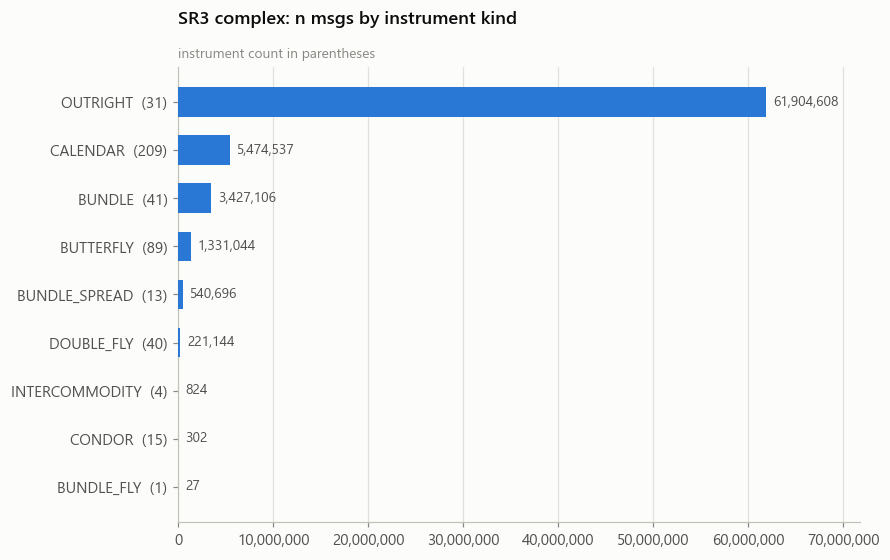

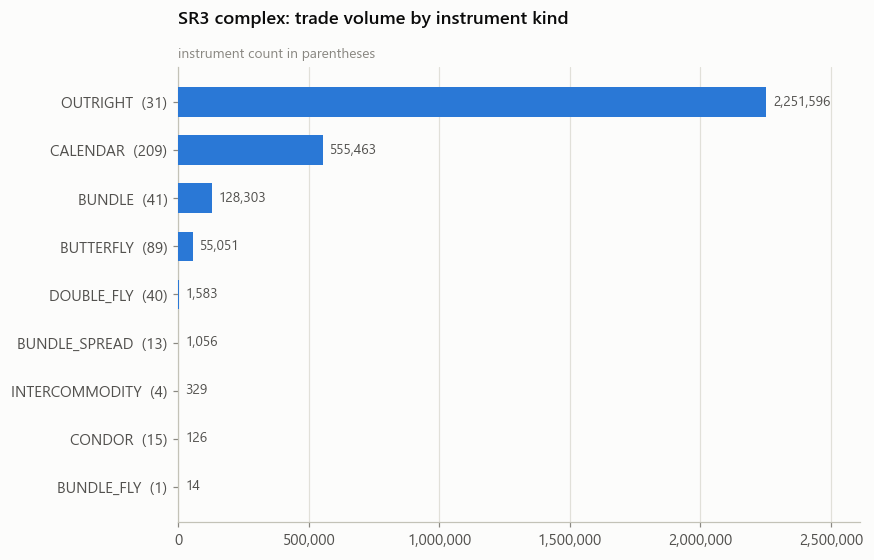

In [3]:
plots.plot_activity_by_kind(cat, metric="n_msgs")
plt.show()
plots.plot_activity_by_kind(cat, metric="trade_volume")
plt.show()

In [4]:
cols = ["symbol", "kind", "label", "n_msgs", "n_trades", "trade_volume",
        "avg_trade_size", "msgs_per_trade", "n_contracts", "px_min", "px_max"]
print("=== busiest outrights ===")
display(cat[cat["kind"] == "OUTRIGHT"].nlargest(12, "n_msgs")[cols])

print("=== busiest listed butterflies ===")
display(cat[cat["kind"] == "BUTTERFLY"].nlargest(12, "trade_volume")[cols])

print("=== busiest calendars ===")
display(cat[cat["kind"] == "CALENDAR"].nlargest(8, "trade_volume")[cols])

=== busiest outrights ===


,symbol,kind,label,n_msgs,n_trades,trade_volume,avg_trade_size,msgs_per_trade,n_contracts,px_min,px_max
0,SR3Z7,OUTRIGHT,SR3Z7,15117140,6759,175342,25.942003,2236.594171,1,95.380,98.300
1,SR3U7,OUTRIGHT,SR3U7,8391902,6459,177264,27.444496,1299.257161,1,95.300,98.300
2,SR3H7,OUTRIGHT,SR3H7,7769777,7692,230816,30.007280,1010.111414,1,95.170,98.300
3,SR3H8,OUTRIGHT,SR3H8,6831844,5178,104922,20.263036,1319.398223,1,95.400,98.300
4,SR3M7,OUTRIGHT,SR3M7,6532499,8371,232317,27.752598,780.372596,1,95.085,98.300
5,SR3M8,OUTRIGHT,SR3M8,6413678,3774,78530,20.808161,1699.437732,1,95.485,98.300
6,SR3U6,OUTRIGHT,SR3U6,6030477,5393,370586,68.716113,1118.204524,1,95.165,98.350
7,SR3Z6,OUTRIGHT,SR3Z6,1108341,9258,495052,53.472888,119.717110,1,95.250,99.035
8,SR3Z8,OUTRIGHT,SR3Z8,462757,3122,55074,17.640615,148.224536,1,95.250,98.300
9,SR3U8,OUTRIGHT,SR3U8,439981,3562,57432,16.123526,123.520775,1,95.495,98.300


=== busiest listed butterflies ===


,symbol,kind,label,n_msgs,n_trades,trade_volume,avg_trade_size,msgs_per_trade,n_contracts,px_min,px_max
64,SR3:BF Z6-H7-M7,BUTTERFLY,3m fly,68800,164,8008,48.829268,419.512195,4,-9.0,22.5
132,SR3:BF U6-Z6-H7,BUTTERFLY,3m fly,32085,404,6839,16.928218,79.418317,4,-14.0,21.5
58,SR3:BF U7-Z7-H8,BUTTERFLY,3m fly,76983,107,4553,42.551402,719.467290,4,-10.0,3.5
173,SR3:BF Z6-M7-Z7,BUTTERFLY,6m fly,19212,310,4198,13.541935,61.974194,4,-13.5,28.5
78,SR3:BF Z7-H8-M8,BUTTERFLY,3m fly,58485,37,3427,92.621622,1580.675676,4,-7.0,3.5
133,SR3:BF M7-M8-M9,BUTTERFLY,12m fly,31088,277,3067,11.072202,112.231047,4,-22.5,-4.0
56,SR3:BF M7-U7-Z7,BUTTERFLY,3m fly,80233,180,3026,16.811111,445.738889,4,-6.5,8.5
225,SR3:BF U6-H7-U7,BUTTERFLY,6m fly,10684,391,2957,7.562660,27.324808,4,14.0,34.0
116,SR3:BF M7-Z7-M8,BUTTERFLY,6m fly,37745,121,2602,21.504132,311.942149,4,-22.0,3.5
47,SR3:BF H7-M7-U7,BUTTERFLY,3m fly,87574,87,1887,21.689655,1006.597701,4,-9.0,9.5


=== busiest calendars ===


,symbol,kind,label,n_msgs,n_trades,trade_volume,avg_trade_size,msgs_per_trade,n_contracts,px_min,px_max
63,SR3H7-SR3M7,CALENDAR,3m calendar,68901,511,76669,150.037182,134.835616,2,-50.0,51.5
95,SR3M7-SR3U7,CALENDAR,3m calendar,48127,283,52521,185.586572,170.060071,2,-54.0,47.5
33,SR3Z6-SR3Z7,CALENDAR,12m calendar,124493,1090,44304,40.645872,114.213761,2,-40.5,26.5
70,SR3Z6-SR3H7,CALENDAR,3m calendar,65310,680,35050,51.544118,96.044118,2,-43.5,59.5
43,SR3U6-SR3Z6,CALENDAR,3m calendar,95279,1070,33909,31.690654,89.045794,2,-37.5,65.5
66,SR3Z6-SR3M7,CALENDAR,6m calendar,68243,582,26609,45.719931,117.256014,2,-43.5,60.5
39,SR3M7-SR3Z7,CALENDAR,6m calendar,96927,420,16222,38.623810,230.778571,2,-59.0,42.5
57,SR3H7-SR3H8,CALENDAR,12m calendar,78480,538,16140,30.000000,145.873606,2,-21.5,0.0


### The unit trap, up front

Look at `px_min`/`px_max` in the two tables above. Outrights sit near 96;
butterflies sit near zero and go negative. That is not a small price — it is a
**different unit**. CME quotes outrights and bundles in index points
(96.040, tick 0.005) and every differential instrument **directly in basis
points** (6.500, tick 0.5).

Check it against the file's own numbers: SR3Z6 96.040, SR3H7 95.970,
SR3M7 95.960 give a fly of `96.040 − 2(95.970) + 95.960 = 0.060` index points
`= 6.0 bp`, and the listed `SR3:BF Z6-H7-M7` closed at **6.500**.

Treating a butterfly price as index points inflates every spread by 100×: a
one-tick market reads as 50 bp wide. `RVUtils/MBO` derives the scale from the
parsed symbol *and* from the tick the instrument actually printed, and raises
if the two disagree rather than guessing.

In [5]:
unit_check = cat[cat["n_trades"] > 100].copy()
unit_check["bp_per_price_unit"] = unit_check["kind"].map(
    lambda k: bp_per_price_unit(k)
)
unit_check.groupby(["kind", "bp_per_price_unit"]).agg(
    instruments=("symbol", "size"),
    px_lo=("px_min", "min"), px_hi=("px_max", "max"),
)

,,instruments,px_lo,px_hi
kind,bp_per_price_unit,,,
BUNDLE,100.0,9,95.635,96.5275
BUNDLE_SPREAD,1.0,2,-0.120,0.2625
BUTTERFLY,1.0,12,-35.000,41.0000
CALENDAR,1.0,44,-59.000,79.0000
OUTRIGHT,100.0,21,95.085,99.0350


### When the book was busy

The vertical rules mark 12:30 UTC — a scheduled release slot; the file says
only that the complex went from a few thousand messages a minute to a
multiple of that — and 21:00 UTC, the settlement break.

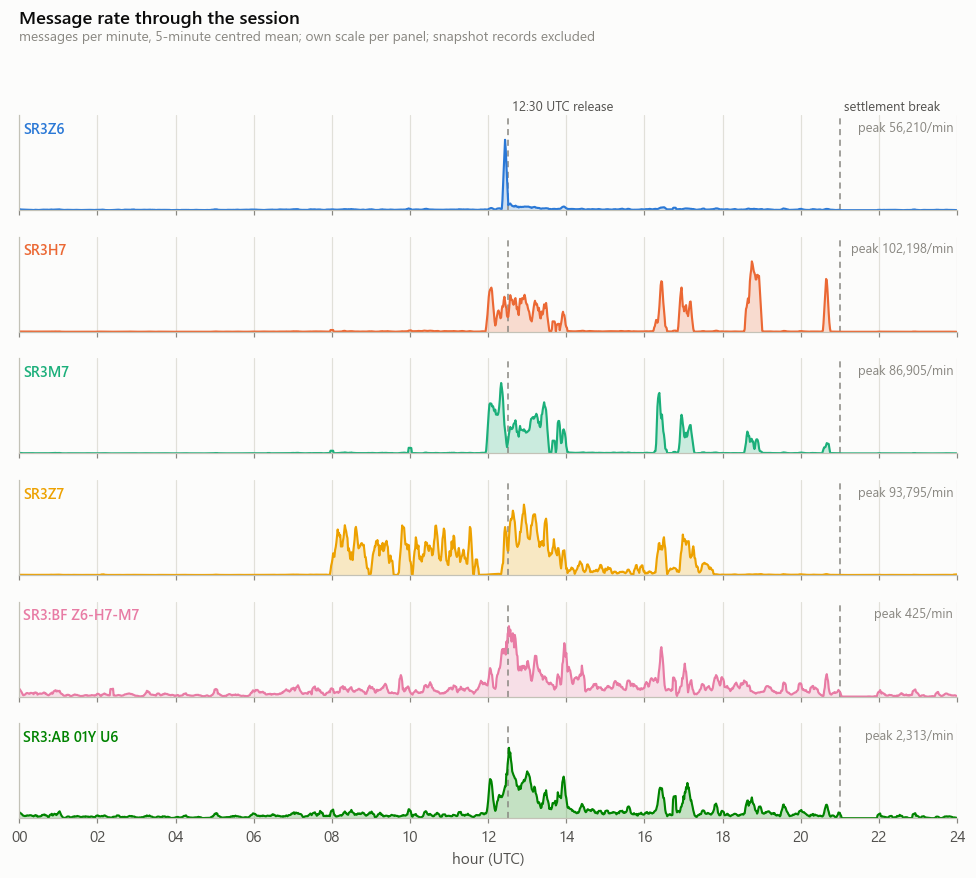

In [6]:
mf = scan.minute_frame("msgs")
watch = ["SR3Z6", "SR3H7", "SR3M7", "SR3Z7", "SR3:BF Z6-H7-M7", "SR3:AB 01Y U6"]
plots.plot_intraday_message_rate(
    mf, [src.symbol_to_id[s] for s in watch],
    labels={src.symbol_to_id[s]: s for s in watch},
    annotate_minutes={12 * 60 + 30: "12:30 UTC release", 21 * 60: "settlement break"},
)
plt.show()

## 2. Book explorer

`replay_book` turns one instrument's messages into a top-of-book event stream
and, optionally, an N-deep ladder on a time grid. The rules that make it
correct are documented in `RVUtils/MBO/book.py`; the two that matter most:

* **`T` and `F` never touch the book.** A match prints as `T`, then `F` on the
  resting order, then an explicit `C` — applying the `F` as well would
  decrement the level twice.
* **Top of book is only read at `F_LAST` packet boundaries.** Inside a packet
  the book is momentarily inconsistent, and a mid taken from one of those
  states poisons every effective-spread number computed off it.

Extraction is batched: pulling one instrument costs a full pass over the file,
so pulling forty costs one pass too.

In [7]:
OUTRIGHTS = ["SR3M6", "SR3U6", "SR3Z6", "SR3H7", "SR3M7", "SR3U7", "SR3Z7",
             "SR3H8", "SR3M8", "SR3U8", "SR3Z8", "SR3M9"]
FLIES = ["SR3:BF Z6-H7-M7", "SR3:BF U6-Z6-H7", "SR3:BF H7-M7-U7", "SR3:BF M7-U7-Z7",
         "SR3:BF U7-Z7-H8", "SR3:BF Z7-H8-M8", "SR3:BF M7-M8-M9", "SR3:BF Z6-M7-Z7",
         "SR3:BF U6-H7-U7", "SR3:BF M7-Z7-M8"]
CALENDARS = ["SR3H7-SR3M7", "SR3M7-SR3U7", "SR3Z6-SR3Z7", "SR3U6-SR3Z6", "SR3Z6-SR3H7"]
PACKS = ["SR3:AB 01Y U6", "SR3:AB 02Y U6"]

UNIVERSE = [s for s in OUTRIGHTS + FLIES + CALENDARS + PACKS if s in src.symbol_to_id]
t0 = time.perf_counter()
written = src.extract([src.symbol_to_id[s] for s in UNIVERSE])
print(f"{len(UNIVERSE)} instruments in the working set; {len(written)} newly extracted "
      f"in {time.perf_counter() - t0:.0f}s")


def replay(symbol: str, grid_freq: str | None = None, n_levels: int = 10):
    """Replay one instrument, with the price scale checked two ways.

    Deliberately *not* cached. The busiest outright changes its touch fifteen
    million times in a day; holding all twelve at full resolution is several
    gigabytes. Everything below either keeps one book at a time or immediately
    reduces to a one-second panel.
    """
    rec = src.records(symbol)
    grid = None
    if grid_freq:
        g = pd.date_range(src.session_start, src.session_end, freq=grid_freq,
                          inclusive="left")
        grid = g.to_numpy(dtype="datetime64[ns]").astype("int64")
    pg = build_price_grid(rec["price"].astype("int64"))
    scale = bp_per_price_unit(src.parsed[symbol].kind, pg.tick_float)
    return replay_book(rec, grid_ts=grid, n_levels=n_levels, grid=pg, bp_per_unit=scale)

29 instruments in the working set; 0 newly extracted in 0s


In [8]:
t0 = time.perf_counter()
front = replay("SR3Z6", grid_freq="1s", n_levels=10)
print(f"SR3Z6: {front.n_records:,} records replayed in {time.perf_counter() - t0:.1f}s")
print(f"  snapshot rows      {front.n_snapshot:,}")
print(f"  top-of-book events {len(front.tob):,}")
print(f"  trades             {len(front.trades):,}  ({front.trades['size'].sum():,} lots)")
print(f"  price ladder       tick {front.grid.tick_float:g} "
      f"({front.grid.tick_float * front.bp_per_unit:g} bp), {front.grid.n_slots} slots")
print(f"  price scale        {front.bp_per_unit:g} bp per price unit")
print(f"  crossed at a packet boundary: {front.crossed_events:,}")
front.tob.head()

SR3Z6: 1,108,341 records replayed in 2.1s
  snapshot rows      1,863
  top-of-book events 962,505
  trades             9,258  (495,052 lots)
  price ladder       tick 0.005 (0.5 bp), 758 slots
  price scale        100 bp per price unit
  crossed at a packet boundary: 0


,rec_idx,ts_recv,ts_event,bid_px,bid_sz,bid_ct,ask_px,ask_sz,ask_ct,mid,spread
0,1863,2026-07-15 00:00:00.069215204+00:00,2026-07-15 00:00:00.068231699+00:00,95.995,7557,36,96.0,1257,8,95.9975,0.005
1,1864,2026-07-15 00:00:00.069543027+00:00,2026-07-15 00:00:00.069135461+00:00,95.995,7550,35,96.0,1257,8,95.9975,0.005
2,1865,2026-07-15 00:00:00.071859131+00:00,2026-07-15 00:00:00.071710961+00:00,95.995,7551,35,96.0,1257,8,95.9975,0.005
3,1866,2026-07-15 00:00:00.071992300+00:00,2026-07-15 00:00:00.071864037+00:00,95.995,7553,35,96.0,1257,8,95.9975,0.005
4,1867,2026-07-15 00:00:00.074630570+00:00,2026-07-15 00:00:00.074507055+00:00,95.995,7553,35,96.0,1422,9,95.9975,0.005


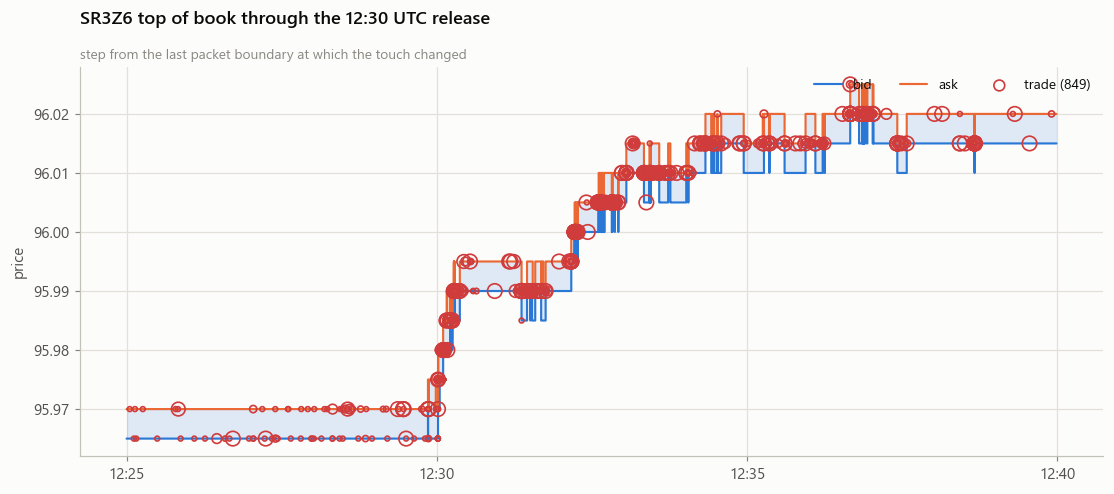

In [9]:
WINDOW = ("2026-07-15 12:25:00+00:00", "2026-07-15 12:40:00+00:00")
plots.plot_top_of_book(front.tob, front.trades, session=WINDOW,
                       title="SR3Z6 top of book through the 12:30 UTC release")
plt.show()

The depth ladder shows what the touch chart cannot: how much size rests behind
the best price, and whether it leaves before or after the print.

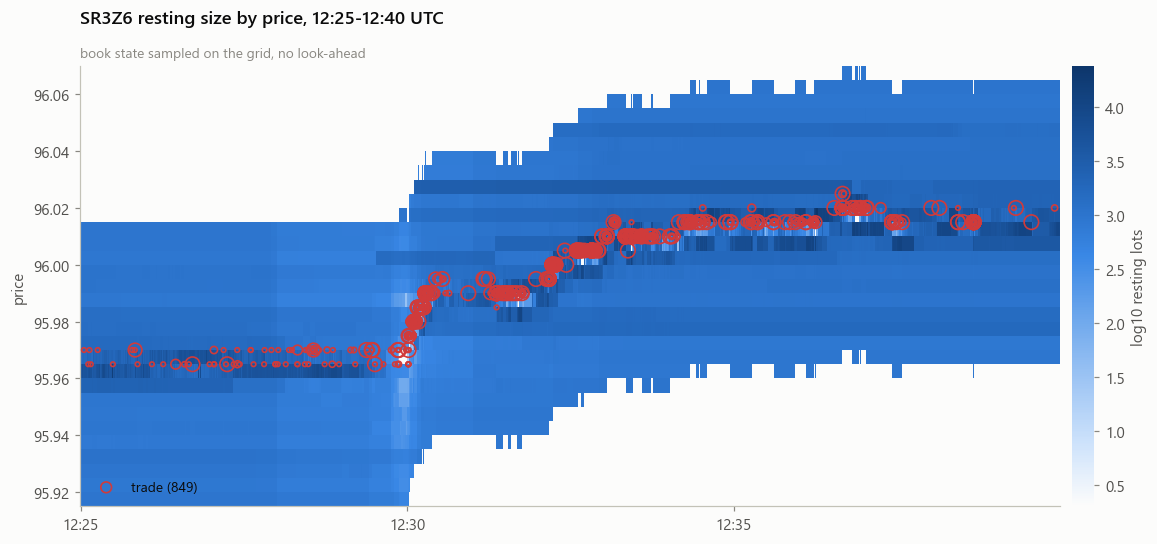

In [10]:
gts = pd.to_datetime(front.depth["ts"], utc=True)
sel = (gts >= pd.Timestamp(WINDOW[0])) & (gts < pd.Timestamp(WINDOW[1]))
plots.plot_depth_heatmap({k: v[sel] for k, v in front.depth.items()}, front.trades,
                         title="SR3Z6 resting size by price, 12:25-12:40 UTC")
plt.show()

### Does the flow move the price?

Two measures of pressure against the move that came with it. **Signed trade
flow** is aggressor buys minus aggressor sells; **order-flow imbalance** is
the Cont-Kukanov-Stoikov measure built from top-of-book transitions, which
counts resting size that never traded.

Signed trade flow works at any horizon. OFI does not work at one minute in
this book and does at five — which is a property of the instrument, not a
defect: the touch holds thousands of lots and the mid only moves when a whole
level clears, so a single minute of queue churn is mostly noise around an
unmoved price. That the *trade* relation is positive is also the check that
the aggressor convention and the mid are consistent.

,bars,r_signed_trade,r_ofi,bp_per_1000_lots_trade,bp_per_1000_lots_ofi
freq,,,,,
1min,540,0.3146,-0.1338,0.0793,-0.0022
5min,108,0.3804,0.1859,0.1026,0.0031
15min,36,0.1474,0.0095,0.0403,0.0002


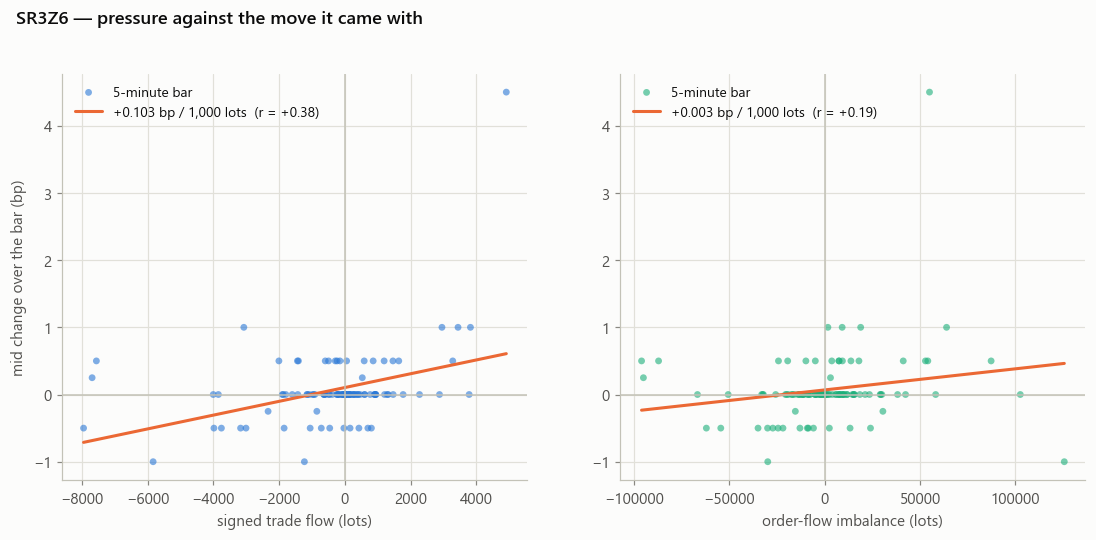

In [11]:
def flow_panel(res, freq):
    ofi = order_flow_imbalance(res.tob, freq=freq, bp_per_unit=res.bp_per_unit)
    t = res.trades.copy()
    t["signed"] = np.where(t["aggressor"] == "B", 1, -1) * t["size"]
    sv = t.set_index("ts_recv")["signed"].resample(freq).sum()
    d = ofi.join(sv.rename("signed_vol")).dropna()
    return d[(d.index >= pd.Timestamp(RTH[0])) & (d.index < pd.Timestamp(RTH[1]))]


rows_flow = []
for freq in ("1min", "5min", "15min"):
    d = flow_panel(front, freq)
    rows_flow.append({
        "freq": freq, "bars": len(d),
        "r_signed_trade": d["signed_vol"].corr(d["mid_change_bp"]),
        "r_ofi": d["ofi"].corr(d["mid_change_bp"]),
        "bp_per_1000_lots_trade": np.polyfit(d["signed_vol"], d["mid_change_bp"], 1)[0] * 1000,
        "bp_per_1000_lots_ofi": np.polyfit(d["ofi"], d["mid_change_bp"], 1)[0] * 1000,
    })
display(pd.DataFrame(rows_flow).set_index("freq").round(4))

d5 = flow_panel(front, "5min")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, col, name, i in ((axes[0], "signed_vol", "signed trade flow", 0),
                         (axes[1], "ofi", "order-flow imbalance", 2)):
    ax.scatter(d5[col], d5["mid_change_bp"], s=20, color=plots.series_color(i),
               alpha=0.6, edgecolor="none", label="5-minute bar")
    slope, intercept = np.polyfit(d5[col], d5["mid_change_bp"], 1)
    xs = np.linspace(d5[col].min(), d5[col].max(), 50)
    ax.plot(xs, intercept + slope * xs, color=plots.SERIES[1], lw=2.0,
            label=f"{slope * 1000:+.3f} bp / 1,000 lots  "
                  f"(r = {d5[col].corr(d5['mid_change_bp']):+.2f})")
    ax.axhline(0, color=plots.BASELINE, lw=1.0)
    ax.axvline(0, color=plots.BASELINE, lw=1.0)
    ax.set_xlabel(f"{name} (lots)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("mid change over the bar (bp)")
fig.suptitle("SR3Z6 — pressure against the move it came with", x=0.09, y=1.0,
             ha="left", fontsize=12, fontweight="600", color=plots.INK)
plt.show()

### The same machinery on a listed butterfly

This is the object the repo has never been able to look at: a fly with its own
book, its own tick, and its own resting size.

SR3:BF Z6-H7-M7: 68,800 records, 64,953 top-of-book events, 164 trades (8,008 lots)
  tick 0.5 price units = 0.5 bp


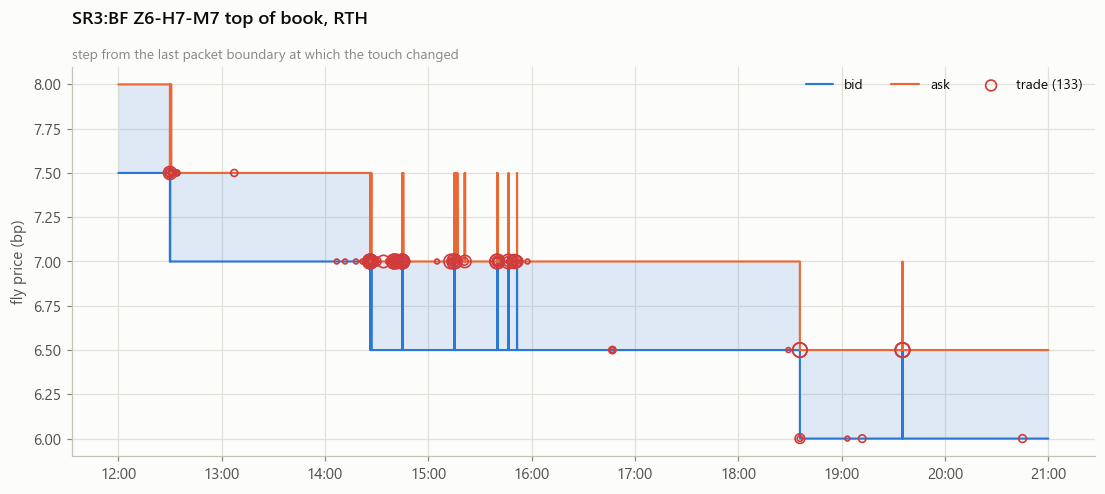

In [12]:
del front
gc.collect()

FLY = "SR3:BF Z6-H7-M7"
fly = replay(FLY, grid_freq="5s", n_levels=6)   # 5s over nine hours stays legible
print(f"{FLY}: {fly.n_records:,} records, {len(fly.tob):,} top-of-book events, "
      f"{len(fly.trades):,} trades ({fly.trades['size'].sum():,} lots)")
print(f"  tick {fly.grid.tick_float:g} price units = "
      f"{fly.grid.tick_float * fly.bp_per_unit:g} bp")
plots.plot_top_of_book(fly.tob, fly.trades, session=RTH,
                       title=f"{FLY} top of book, RTH", price_label="fly price (bp)")
plt.show()

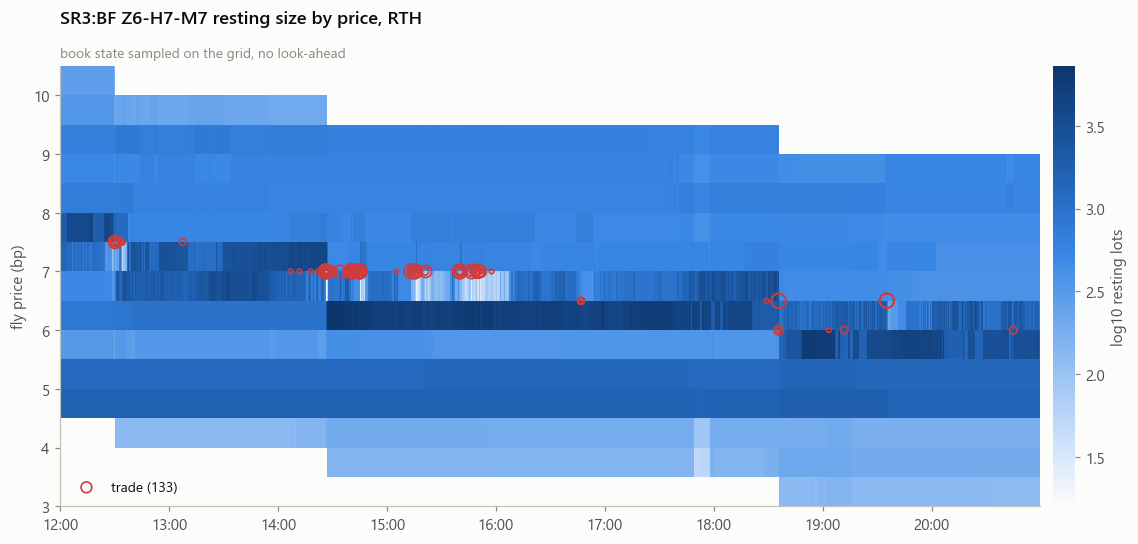

In [13]:
gts = pd.to_datetime(fly.depth["ts"], utc=True)
sel = (gts >= pd.Timestamp(RTH[0])) & (gts < pd.Timestamp(RTH[1]))
plots.plot_depth_heatmap({k: v[sel] for k, v in fly.depth.items()}, fly.trades,
                         title=f"{FLY} resting size by price, RTH",
                         price_label="fly price (bp)")
plt.show()

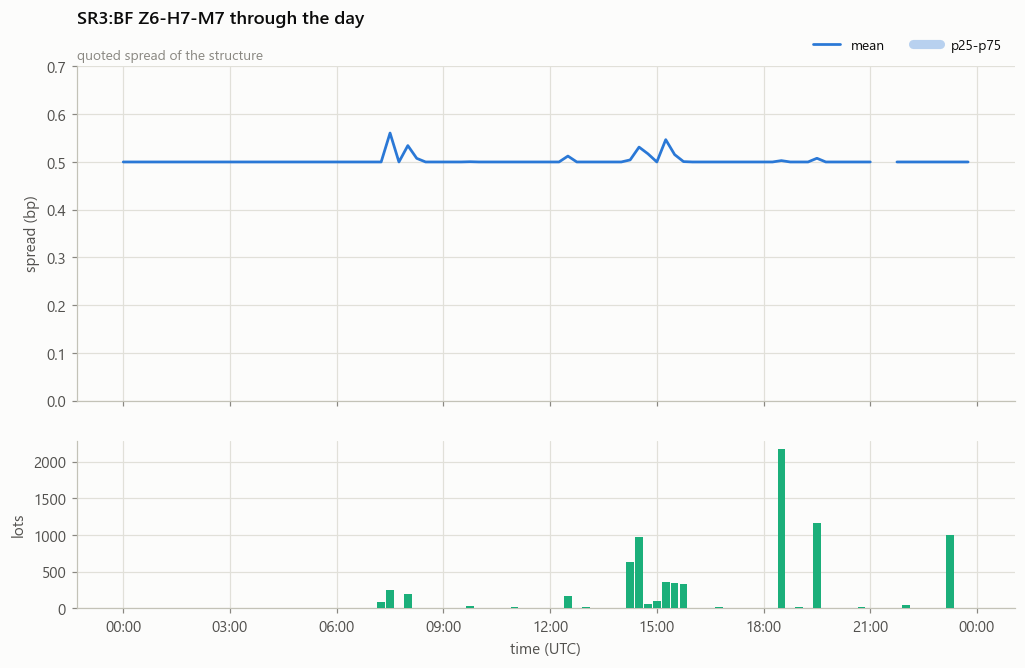

In [14]:
prof = intraday_profile(fly.tob, fly.trades, freq="15min", bp_per_unit=fly.bp_per_unit)
plots.plot_intraday_profile(prof, title=f"{FLY} through the day")
plt.show()

## 3. Cost truth

Three numbers, all in **bp of the structure** ($25 per bp per lot):

* **quoted spread** — time-weighted, so a wide state that stood for ten
  minutes counts for ten minutes and not for one event
* **effective spread** — `2 × direction × (price − prevailing mid)`: what the
  trades that actually happened paid
* **realised spread** at 60 s, and the difference, which is impact

`two_sided_frac` is the guard: a tight spread that exists only 4% of the day
is not a spread you can trade, and an average would hide that.

Each instrument is replayed, summarised and discarded, plus its one-second
panel kept for the leg-implied comparison in section 4.

In [15]:
rows, leg_panels, invariants, all_trades = [], {}, [], {}

for sym in UNIVERSE:
    r = replay(sym)
    p = src.parsed[sym]

    q = quoted_spread_summary(r.tob, n_contracts=p.n_contracts, session=RTH,
                              tick=r.grid.tick_float, bp_per_unit=r.bp_per_unit)
    eff = effective_spread(r.tob, r.trades, horizons_s=(1.0, 60.0), session=RTH,
                           bp_per_unit=r.bp_per_unit)
    rows.append(dict(
        symbol=sym, kind=p.kind, label=p.label, n_contracts=p.n_contracts,
        usd_per_bp=p.usd_per_bp_per_lot,
        tick_bp=r.grid.tick_float * r.bp_per_unit,
        n_trades=int(len(eff)), lots=int(eff["size"].sum()) if len(eff) else 0,
        **{k: q.get(k) for k in ("spread_bp", "spread_bp_median", "two_sided_frac",
                                 "bid_sz_at_touch", "ask_sz_at_touch",
                                 "orders_at_touch", "frac_time_one_tick")},
        eff_bp=float(eff["eff_bp"].median()) if len(eff) else np.nan,
        realised_bp_60s=float(eff["realised_bp_60s"].median()) if len(eff) else np.nan,
        impact_bp_60s=float(eff["impact_bp_60s"].median()) if len(eff) else np.nan,
    ))

    full = effective_spread(r.tob, r.trades, horizons_s=(),
                            bp_per_unit=r.bp_per_unit).dropna(subset=["bid_px", "ask_px"])
    outside = (full["price"] > full["ask_px"] + 1e-12) | (full["price"] < full["bid_px"] - 1e-12)
    invariants.append(dict(
        symbol=sym, kind=p.kind, records=r.n_records, snapshot=r.n_snapshot,
        tob_events=len(r.tob), crossed_at_boundary=r.crossed_events,
        trades_checked=int(len(full)), trades_outside_book=int(outside.sum()),
        frac_outside=float(outside.mean()) if len(full) else np.nan,
    ))

    panel = resample_tob(r.tob, freq="1s", session=RTH, bp_per_unit=r.bp_per_unit)
    if not panel.empty:
        leg_panels[sym] = panel.reset_index()
    all_trades[sym] = r.trades

    del r, eff, full
    gc.collect()

cost = cost_summary(rows, legged_bp_per_contract=0.5)
show = ["symbol", "kind", "n_contracts", "usd_per_bp", "tick_bp", "spread_bp",
        "spread_bp_median", "eff_bp", "impact_bp_60s", "two_sided_frac",
        "frac_time_one_tick", "bid_sz_at_touch", "ask_sz_at_touch",
        "orders_at_touch", "n_trades", "lots",
        "legged_roundtrip_bp", "listed_roundtrip_bp", "cost_ratio",
        "listed_roundtrip_usd", "legged_roundtrip_usd"]
cost.sort_values(["kind", "cost_ratio"])[show]

,symbol,kind,n_contracts,usd_per_bp,tick_bp,spread_bp,spread_bp_median,eff_bp,impact_bp_60s,two_sided_frac,frac_time_one_tick,bid_sz_at_touch,ask_sz_at_touch,orders_at_touch,n_trades,lots,legged_roundtrip_bp,listed_roundtrip_bp,cost_ratio,listed_roundtrip_usd,legged_roundtrip_usd
28,SR3:AB 02Y U6,BUNDLE,8,200.0,0.25,0.272296,0.25,0.25,0.25,0.999872,0.911613,107.637412,108.559554,26.177316,3855,21821,4.0,0.272296,0.068074,54.459150,800.0
27,SR3:AB 01Y U6,BUNDLE,4,100.0,0.25,0.272539,0.25,0.25,0.00,1.000000,0.915888,148.771183,160.621641,24.264117,3584,29117,2.0,0.272539,0.136269,27.253890,200.0
17,SR3:BF Z7-H8-M8,BUTTERFLY,4,25.0,0.50,0.500000,0.50,0.50,0.00,1.000000,1.000000,2172.738278,13014.503718,47.006671,36,1427,2.0,0.500000,0.250000,12.500000,50.0
14,SR3:BF H7-M7-U7,BUTTERFLY,4,25.0,0.50,0.500002,0.50,0.50,0.00,1.000000,0.999997,2531.785724,1778.148744,37.575560,82,1878,2.0,0.500002,0.250001,12.500040,50.0
12,SR3:BF Z6-H7-M7,BUTTERFLY,4,25.0,0.50,0.500768,0.50,0.50,0.00,1.000000,0.998464,3619.476658,1633.772896,42.295295,133,6384,2.0,0.500768,0.250384,12.519197,50.0
15,SR3:BF M7-U7-Z7,BUTTERFLY,4,25.0,0.50,0.501240,0.50,0.50,0.00,1.000000,0.997520,2802.620959,2503.141599,34.420231,174,2876,2.0,0.501240,0.250620,12.530996,50.0
16,SR3:BF U7-Z7-H8,BUTTERFLY,4,25.0,0.50,0.503049,0.50,0.50,1.00,1.000000,0.993902,3129.256549,4667.939158,42.756952,87,2150,2.0,0.503049,0.251525,12.576228,50.0
13,SR3:BF U6-Z6-H7,BUTTERFLY,4,25.0,0.50,0.509311,0.50,0.50,0.00,1.000000,0.981377,636.037402,826.014155,23.878340,318,4997,2.0,0.509311,0.254656,12.732786,50.0
21,SR3:BF M7-Z7-M8,BUTTERFLY,4,25.0,0.50,0.571366,0.50,0.50,0.50,1.000000,0.857269,361.698060,678.878171,15.613970,105,2480,2.0,0.571366,0.285683,14.284139,50.0
18,SR3:BF M7-M8-M9,BUTTERFLY,4,25.0,0.50,0.600234,0.50,0.50,0.50,1.000000,0.799533,145.254384,152.394290,9.778509,261,2977,2.0,0.600234,0.300117,15.005839,50.0


`legged_roundtrip_bp` is the repo's standing assumption applied to the
structure: `n_contracts × 0.5 bp`, which is **2.0 bp for a butterfly**.
`listed_roundtrip_bp` is what crossing the instrument's own book costs.
`cost_ratio` below 1 means the listed book is cheaper than what every backtest
in this repo has been charging.

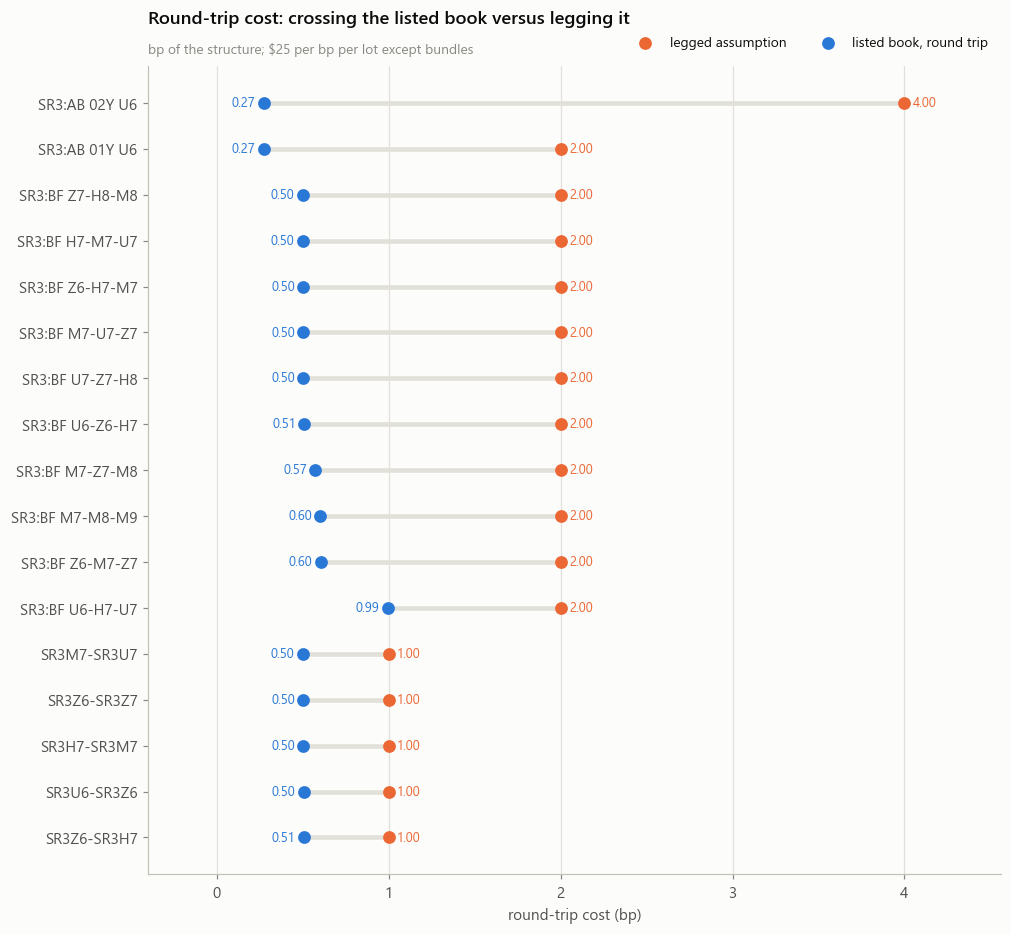

listed butterflies (n=10):
  median quoted round trip   0.506 bp ($12.65 per lot)
  legged assumption          2.000 bp ($50.00 per lot)
  ratio                      0.25x
  median effective spread    0.500 bp
  two-sided share of RTH     100.0% - 100.0%


In [16]:
structures = cost[cost["kind"].isin(["BUTTERFLY", "CALENDAR", "BUNDLE"])]
plots.plot_cost_comparison(structures, top=len(structures))
plt.show()

headline = cost[cost["kind"] == "BUTTERFLY"]
print(f"listed butterflies (n={len(headline)}):")
print(f"  median quoted round trip   {headline['listed_roundtrip_bp'].median():.3f} bp "
      f"(${headline['listed_roundtrip_usd'].median():.2f} per lot)")
print(f"  legged assumption          {headline['legged_roundtrip_bp'].median():.3f} bp "
      f"(${headline['legged_roundtrip_usd'].median():.2f} per lot)")
print(f"  ratio                      {headline['cost_ratio'].median():.2f}x")
print(f"  median effective spread    {headline['eff_bp'].median():.3f} bp")
print(f"  two-sided share of RTH     {headline['two_sided_frac'].min():.1%} "
      f"- {headline['two_sided_frac'].max():.1%}")

Read that against the cost line every SR3 study in this repo carries. The
listed butterfly is quoted **one tick wide** — the same one tick as an
outright — so a round trip costs the tick, not four times it. Section 4
checks the obvious objection: that this is CME's implied liquidity in
disguise, and the fly is really only as good as its legs.

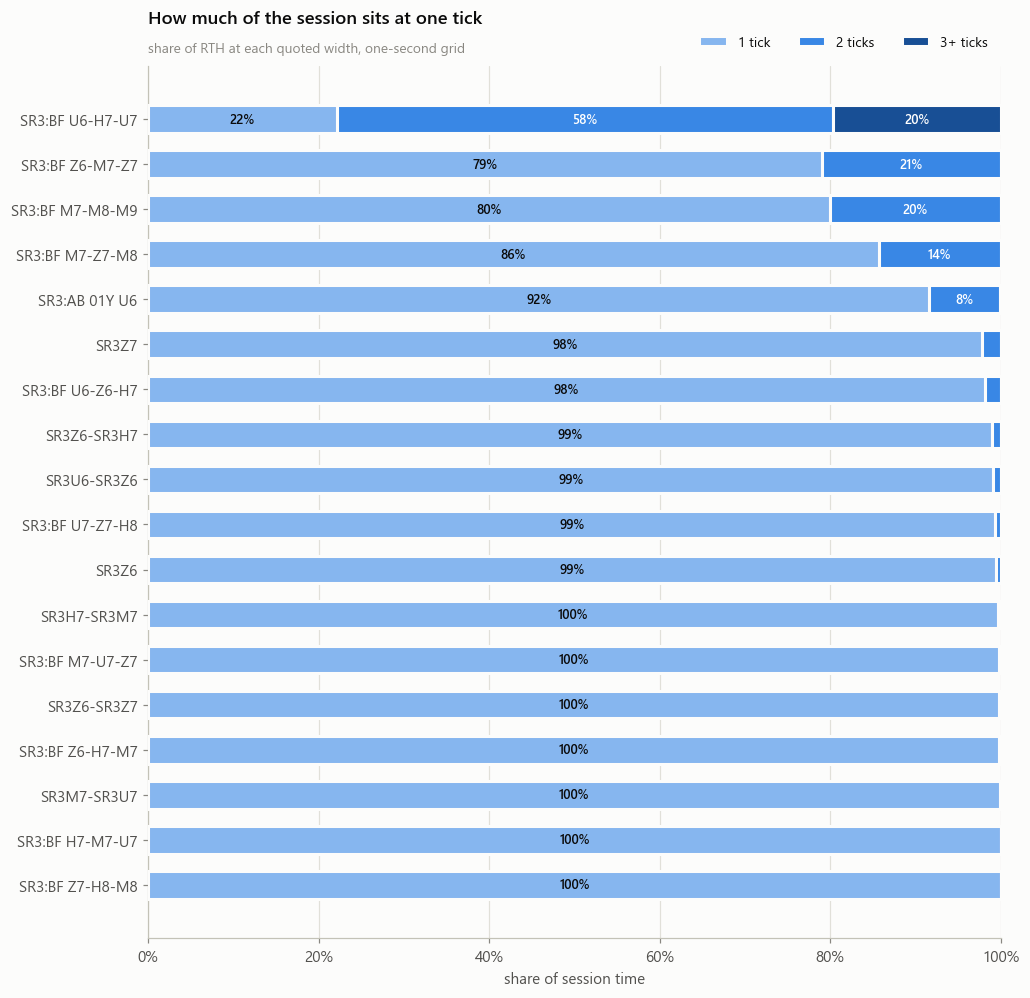

In [17]:
def width_share(symbols):
    """Share of RTH seconds at 1 / 2 / 3+ ticks, per instrument."""
    out = {}
    for sym in symbols:
        p = leg_panels.get(sym)
        if p is None:
            continue
        tick = cost.loc[cost["symbol"] == sym, "tick_bp"].iloc[0]
        n = (p["spread_bp"] / tick).round().dropna()
        out[sym] = pd.Series({
            "1 tick": float((n <= 1).mean()),
            "2 ticks": float((n == 2).mean()),
            "3+ ticks": float((n >= 3).mean()),
        })
    return pd.DataFrame(out).T


shares = width_share(FLIES + CALENDARS + ["SR3Z6", "SR3Z7", "SR3:AB 01Y U6"])
plots.plot_spread_time_share(shares.sort_values("1 tick"))
plt.show()

## 4. Listed against implied

A butterfly can be bought two ways: cross its own book, or cross the three
outright books. To *buy* the structure you lift the ask on positive legs and
hit the bid on negative ones, so the leg-implied **ask** uses the **bid** of
the doubled belly. Getting that backwards makes the synthetic look tighter
than it is, which is the conclusion this comparison exists to test.

Both sides are converted to basis points first — the legs quote in index
points and the listed structure quotes in bp, so a raw comparison would be
meaningless. The sign convention is not assumed either: the comparison fits
both orientations against the listed mid and reports which it used.

In [18]:
cmp_fly = compare_listed_vs_implied(
    fly.tob, leg_panels, src.parsed[FLY].legs, src.parsed[FLY].weights,
    freq="1s", session=RTH, listed_bp_per_unit=fly.bp_per_unit,
)
print(cmp_fly)
pd.Series(cmp_fly.stats)

<ImpliedComparison orientation=+1 listed=0.500bp implied=2.000bp listed_tighter=100.0%>


n                        32399.000000
orientation                  1.000000
mid_abs_err_bp               0.250000
listed_spread_bp             0.500000
implied_spread_bp            2.000000
frac_listed_tighter          1.000000
listed_sz_at_touch        2261.000000
implied_sz_at_touch        286.000000
frac_listed_two_sided        0.999969
frac_listed_crossable        0.000000
dtype: float64

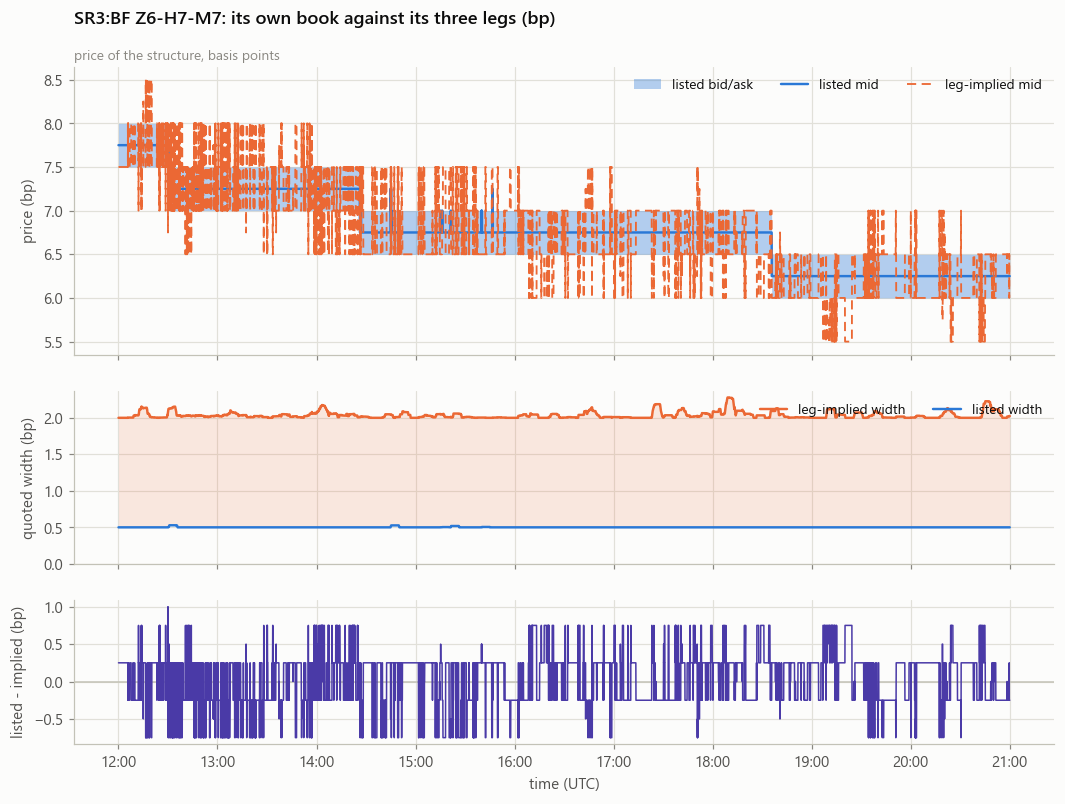

In [19]:
plots.plot_listed_vs_implied(cmp_fly.frame.dropna(subset=["listed_mid"]),
                             title=f"{FLY}: its own book against its three legs (bp)")
plt.show()

In [20]:
imp_rows = []
for sym in FLIES + CALENDARS:
    p = src.parsed[sym]
    if any(l not in leg_panels for l in p.legs):
        continue
    r = replay(sym)
    c = compare_listed_vs_implied(r.tob, leg_panels, p.legs, p.weights, freq="1s",
                                  session=RTH, listed_bp_per_unit=r.bp_per_unit)
    imp_rows.append({"symbol": sym, "kind": p.kind, "label": p.label, **c.stats})
    del r, c
    gc.collect()

implied = pd.DataFrame(imp_rows)
implied.sort_values(["kind", "listed_spread_bp"])

,symbol,kind,label,n,orientation,mid_abs_err_bp,listed_spread_bp,implied_spread_bp,frac_listed_tighter,listed_sz_at_touch,implied_sz_at_touch,frac_listed_two_sided,frac_listed_crossable
0,SR3:BF Z6-H7-M7,BUTTERFLY,3m fly,32399,1,0.25,0.5,2.0,1.000000,2261.0,286.0,0.999969,0.0
1,SR3:BF U6-Z6-H7,BUTTERFLY,3m fly,32374,1,0.25,0.5,2.0,1.000000,639.0,485.0,0.999198,0.0
2,SR3:BF H7-M7-U7,BUTTERFLY,3m fly,32400,1,0.25,0.5,2.0,1.000000,1825.0,207.0,1.000000,0.0
3,SR3:BF M7-U7-Z7,BUTTERFLY,3m fly,32398,1,0.25,0.5,2.0,1.000000,2076.0,215.0,0.999938,0.0
4,SR3:BF U7-Z7-H8,BUTTERFLY,3m fly,32398,1,0.25,0.5,2.0,1.000000,3883.0,243.0,0.999938,0.0
5,SR3:BF Z7-H8-M8,BUTTERFLY,3m fly,32400,1,0.25,0.5,2.0,1.000000,4122.0,135.0,1.000000,0.0
6,SR3:BF M7-M8-M9,BUTTERFLY,12m fly,32398,1,0.25,0.5,2.0,1.000000,100.0,75.0,1.000000,0.0
7,SR3:BF Z6-M7-Z7,BUTTERFLY,6m fly,32399,1,0.25,0.5,2.0,1.000000,82.0,265.0,1.000000,0.0
9,SR3:BF M7-Z7-M8,BUTTERFLY,6m fly,32400,1,0.25,0.5,2.0,1.000000,402.0,151.0,1.000000,0.0
8,SR3:BF U6-H7-U7,BUTTERFLY,6m fly,32400,1,0.25,1.0,2.0,1.000000,24.0,329.5,1.000000,0.0


The column that settles the question is `listed_spread_bp` against
`implied_spread_bp`. Crossing three outright books to build a fly costs each
leg's half-spread weighted by its ratio — `0.5 + 2(0.5) + 0.5 = 2.0 bp`, which
is exactly the legged assumption, now measured rather than assumed.

### The third route

Outrights are not the only way to leg a fly. `Z6-H7-M7` is also the difference
of two listed calendars, `(Z6−H7) − (H7−M7)`, and both of those are quoted at
half a basis point — so the calendar route costs `2 × 0.5 = 1.0 bp`, half the
outright route. It is the fairest comparison available, and the listed fly
still wins it.

In [21]:
CAL_ROUTE = ("SR3Z6-SR3H7", "SR3H7-SR3M7")      # (Z6-H7) - (H7-M7) == Z6 - 2H7 + M7
cmp_cal = compare_listed_vs_implied(
    fly.tob, leg_panels, CAL_ROUTE, (1, -1), freq="1s", session=RTH,
    listed_bp_per_unit=fly.bp_per_unit,
    leg_bp_per_unit=1.0,                        # calendars already quote in bp
)
routes = pd.DataFrame([
    {"route": "listed butterfly", "width_bp": cmp_fly.stats["listed_spread_bp"],
     "size_at_touch": cmp_fly.stats["listed_sz_at_touch"]},
    {"route": "two listed calendars", "width_bp": cmp_cal.stats["implied_spread_bp"],
     "size_at_touch": cmp_cal.stats["implied_sz_at_touch"]},
    {"route": "three outrights", "width_bp": cmp_fly.stats["implied_spread_bp"],
     "size_at_touch": cmp_fly.stats["implied_sz_at_touch"]},
])
routes["usd_per_lot"] = routes["width_bp"] * USD_PER_BP_PER_LOT
routes["vs_listed"] = routes["width_bp"] / routes["width_bp"].iloc[0]
print(f"{FLY} — three ways to trade the same structure, RTH medians")
print(f"calendar route mid agrees with the listed mid to "
      f"{cmp_cal.stats['mid_abs_err_bp']:.2f} bp")
routes

SR3:BF Z6-H7-M7 — three ways to trade the same structure, RTH medians
calendar route mid agrees with the listed mid to 0.25 bp


,route,width_bp,size_at_touch,usd_per_lot,vs_listed
0,listed butterfly,0.5,2261.0,12.5,1.0
1,two listed calendars,1.0,753.0,25.0,2.0
2,three outrights,2.0,286.0,50.0,4.0


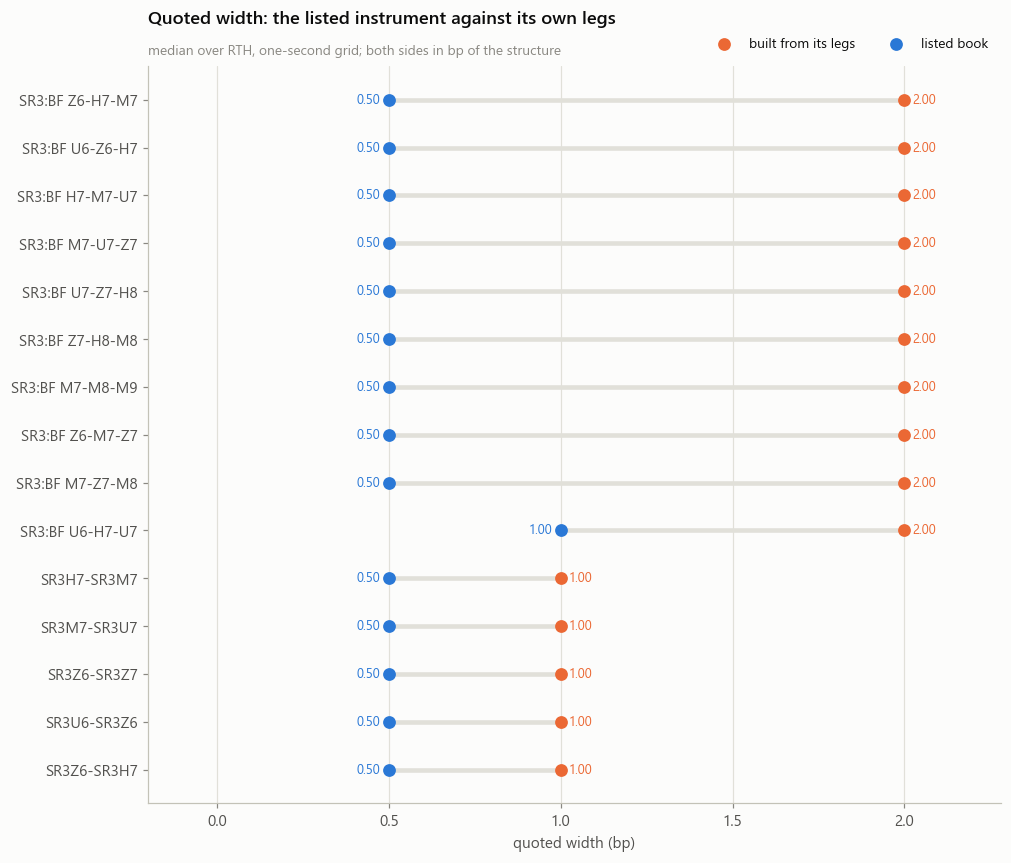

In [22]:
plots.plot_paired_dots(
    implied.sort_values(["kind", "listed_spread_bp"]),
    "symbol", "listed_spread_bp", "implied_spread_bp",
    "listed book", "built from its legs",
    "Quoted width: the listed instrument against its own legs",
    "median over RTH, one-second grid; both sides in bp of the structure",
    "quoted width (bp)",
)
plt.show()

## 5. RV panel

The touch on a regular grid, forward-filled from its own events and already in
basis points — the shape `RVUtils` wants. Written to the cache so downstream
work never re-replays.

In [23]:
panels = []
for sym, p in leg_panels.items():
    panels.append(p.assign(symbol=sym, kind=src.parsed[sym].kind,
                           n_contracts=src.parsed[sym].n_contracts))
panel = pd.concat(panels, ignore_index=True)

out = Path(CACHE_DIR) / "sr3_mbo_panel_1s_20260715.parquet"
panel.to_parquet(out, index=False)
print(f"{len(panel):,} rows x {panel['symbol'].nunique()} instruments -> {out}")
print(f"{out.stat().st_size / 1e6:.1f} MB on disk")
panel.head()

939,549 rows x 29 instruments -> C:\Users\chris\clee\mbo_cache\sr3_mbo_panel_1s_20260715.parquet
4.5 MB on disk


,ts_recv,bid_px,bid_sz,ask_px,ask_sz,mid,spread,spread_bp,mid_bp,symbol,kind,n_contracts
0,2026-07-15 12:00:00+00:00,96.3225,52.0,96.325,10015.0,96.32375,0.0025,0.25,9632.375,SR3M6,OUTRIGHT,1
1,2026-07-15 12:00:01+00:00,96.3225,52.0,96.325,10015.0,96.32375,0.0025,0.25,9632.375,SR3M6,OUTRIGHT,1
2,2026-07-15 12:00:02+00:00,96.3225,52.0,96.325,10015.0,96.32375,0.0025,0.25,9632.375,SR3M6,OUTRIGHT,1
3,2026-07-15 12:00:03+00:00,96.3225,152.0,96.325,10015.0,96.32375,0.0025,0.25,9632.375,SR3M6,OUTRIGHT,1
4,2026-07-15 12:00:04+00:00,96.3225,152.0,96.325,10015.0,96.32375,0.0025,0.25,9632.375,SR3M6,OUTRIGHT,1


## 6. Verification

### 6a. Tie-out against an independent source

The repo already holds a Barchart four-hour bar panel covering this day
(`notebooks/data/stir_intraday/contracts.parquet`, built for the intraday-kink
study). Reconstructing the same bars from the MBO trade prints and comparing
closes is a known-answer check: the two paths share no code and no vendor.

The bars are stamped in Chicago time, UTC-5 in July. **Both** labelling
conventions are tested and both results reported, so the alignment is a
finding rather than something fitted to make the check pass.

In [24]:
REL = Path("notebooks") / "data" / "stir_intraday" / "contracts.parquet"
candidates = [REPO / REL] + [p / REL for p in sorted(REPO.parent.glob("ARBS*"))]
bc_path = next((p for p in candidates if p.exists()), None)
if bc_path is None:
    raise FileNotFoundError(
        "Barchart tie-out panel not found. Looked in:\n  "
        + "\n  ".join(str(p) for p in candidates)
    )
print(f"tie-out reference: {bc_path}")

bc = pd.read_parquet(bc_path)
bc = bc[bc["as_of"].dt.date == pd.Timestamp("2026-07-15").date()]
print(f"{len(bc)} Barchart bars on 2026-07-15 across {bc['code'].nunique()} contracts")

MONTH_LETTER = {1: "F", 2: "G", 3: "H", 4: "J", 5: "K", 6: "M",
                7: "N", 8: "Q", 9: "U", 10: "V", 11: "X", 12: "Z"}
CT_OFFSET = pd.Timedelta(hours=5)          # July: America/Chicago is UTC-5

tie = []
for convention, shift in (("labelled by start", pd.Timedelta(0)),
                          ("labelled by end", pd.Timedelta(hours=-4))):
    for sym in OUTRIGHTS:
        trades = all_trades.get(sym)
        if trades is None or trades.empty:
            continue
        m = src.parsed[sym].months[0]
        code = f"SR3{MONTH_LETTER[m.month]}{m.year % 100:02d}"
        ref = bc[bc["code"] == code]
        for _, row in ref.iterrows():
            start = pd.Timestamp(row["as_of"], tz="UTC") + CT_OFFSET + shift
            end = start + pd.Timedelta(hours=4)
            if start < src.session_start or end > src.session_end:
                continue                    # bar not fully inside the file's window
            seg = trades[(trades["ts_recv"] >= start) & (trades["ts_recv"] < end)]
            if seg.empty:
                continue
            tie.append(dict(
                convention=convention, symbol=sym, code=code, bar_start_utc=start,
                mbo_close=float(seg["price"].iloc[-1]), bc_close=float(row["settle"]),
                mbo_volume=int(seg["size"].sum()), bc_volume=int(row["volume"]),
            ))

tiedf = pd.DataFrame(tie)
tiedf["close_diff_bp"] = (tiedf["mbo_close"] - tiedf["bc_close"]) * 100.0
tiedf["volume_ratio"] = tiedf["mbo_volume"] / tiedf["bc_volume"]

summary = (
    tiedf.groupby("convention")
    .agg(bars=("close_diff_bp", "size"),
         exact=("close_diff_bp", lambda s: float((s.abs() < 1e-6).mean())),
         within_half_tick=("close_diff_bp", lambda s: float((s.abs() <= 0.25).mean())),
         median_abs_bp=("close_diff_bp", lambda s: float(s.abs().median())),
         volume_ratio_median=("volume_ratio", "median"),
         volume_ratio_max=("volume_ratio", "max"),
         bars_volume_exact=("volume_ratio", lambda s: float((s == 1.0).mean())))
)
summary

tie-out reference: C:\Users\chris\clee\ARBS\notebooks\data\stir_intraday\contracts.parquet
130 Barchart bars on 2026-07-15 across 22 contracts


,bars,exact,within_half_tick,median_abs_bp,volume_ratio_median,volume_ratio_max,bars_volume_exact
convention,,,,,,,
labelled by end,60,0.233333,0.283333,1.0,0.598761,322.122222,0.00
labelled by start,48,1.000000,1.000000,0.0,1.000000,1.252521,0.75


In [25]:
best = summary["median_abs_bp"].idxmin()
print(f"closest convention: {best}\nall bars under it, worst close difference first:")
tiedf[tiedf["convention"] == best].sort_values("close_diff_bp", key=abs,
                                               ascending=False).head(12)

closest convention: labelled by start
all bars under it, worst close difference first:


,convention,symbol,code,bar_start_utc,mbo_close,bc_close,mbo_volume,bc_volume,close_diff_bp,volume_ratio
0,labelled by start,SR3M6,SR3M26,2026-07-15 05:00:00+00:00,96.3250,96.3250,6993,6993,0.0,1.000000
1,labelled by start,SR3M6,SR3M26,2026-07-15 09:00:00+00:00,96.3350,96.3350,39341,39341,0.0,1.000000
2,labelled by start,SR3M6,SR3M26,2026-07-15 13:00:00+00:00,96.3325,96.3325,16416,16361,0.0,1.003362
3,labelled by start,SR3M6,SR3M26,2026-07-15 17:00:00+00:00,96.3325,96.3325,28991,28991,0.0,1.000000
4,labelled by start,SR3U6,SR3U26,2026-07-15 05:00:00+00:00,96.1250,96.1250,22740,22740,0.0,1.000000
5,labelled by start,SR3U6,SR3U26,2026-07-15 09:00:00+00:00,96.1750,96.1750,136064,136064,0.0,1.000000
6,labelled by start,SR3U6,SR3U26,2026-07-15 13:00:00+00:00,96.1650,96.1650,124015,119265,0.0,1.039827
7,labelled by start,SR3U6,SR3U26,2026-07-15 17:00:00+00:00,96.1650,96.1650,76600,76600,0.0,1.000000
8,labelled by start,SR3Z6,SR3Z26,2026-07-15 05:00:00+00:00,95.9800,95.9800,31360,31360,0.0,1.000000
9,labelled by start,SR3Z6,SR3Z26,2026-07-15 09:00:00+00:00,96.0300,96.0300,167871,167871,0.0,1.000000


Where volume does not tie exactly it is the MBO that is *higher*, and only in
the 13:00 UTC bar. The likely cause is spread-leg executions: a calendar or
butterfly fill delivers contracts into the outright books and prints there,
and a vendor daily bar may or may not include them. The direction is
consistent with that and the closes are unaffected.

### 6b. Replay invariants

Three properties a wrong replay breaks and a right one does not:

* **the book is never crossed at a packet boundary** — a filled order left
  resting shows up here immediately
* **trades print at or inside the prevailing book** — the residue is implied
  matching, where a spread leg executes against the outright book at a price
  the outright's own book never showed
* **the leg-implied mid tracks the listed mid** — three independently replayed
  outright books must agree with a fourth instrument on an arithmetic identity
  none of them knows about

In [26]:
invdf = pd.DataFrame(invariants)
print(f"crossed-at-boundary events across the working set: "
      f"{invdf['crossed_at_boundary'].sum():,} "
      f"of {invdf['tob_events'].sum():,} top-of-book states")
print(f"trades outside the prevailing book: {invdf['trades_outside_book'].sum():,} "
      f"of {invdf['trades_checked'].sum():,} "
      f"({invdf['trades_outside_book'].sum() / max(1, invdf['trades_checked'].sum()):.3%})")
invdf.sort_values("crossed_at_boundary", ascending=False)

crossed-at-boundary events across the working set: 12 of 59,563,338 top-of-book states
trades outside the prevailing book: 33 of 79,700 (0.041%)


,symbol,kind,records,snapshot,tob_events,crossed_at_boundary,trades_checked,trades_outside_book,frac_outside
0,SR3M6,OUTRIGHT,101373,251,75236,12,1636,0,0.000000
1,SR3U6,OUTRIGHT,6030477,1731,5916882,0,5393,5,0.000927
2,SR3Z6,OUTRIGHT,1108341,1863,962505,0,9258,1,0.000108
3,SR3H7,OUTRIGHT,7769777,2322,7610531,0,7692,4,0.000520
4,SR3M7,OUTRIGHT,6532499,2185,6376607,0,8371,2,0.000239
5,SR3U7,OUTRIGHT,8391902,1876,8267675,0,6459,2,0.000310
6,SR3Z7,OUTRIGHT,15117140,1714,15011066,0,6759,3,0.000444
7,SR3H8,OUTRIGHT,6831844,1680,6739114,0,5178,2,0.000386
8,SR3M8,OUTRIGHT,6413678,1417,6332483,0,3774,1,0.000265
9,SR3U8,OUTRIGHT,439981,1025,393043,0,3562,1,0.000281


Both residues are real market behaviour, not replay defects.

**The crossed states are all pre-open.** They belong to one instrument,
SR3M6, and the timestamps put every one of them between 21:46 and 21:53 UTC —
after the 21:00 settlement break and inside the pre-open of the *next*
session, where CME accepts orders but does not match them, so a locked or
crossed book is the expected state. The raw records show the pattern plainly:
a mass cancel at 21:00:00.189, forty-five minutes of nothing, then orders
building up from 21:45. None of it is inside RTH.

**Trades outside the book are implied matching.** They appear only on
outrights and bundles, never on a listed spread, at rates of 0.01–0.10%. A
spread order can execute against the outright book at a price the outright's
own book never displayed, and the print lands outside it.

In [27]:
front_cross = replay("SR3M6").tob
front_cross = front_cross[front_cross["bid_px"] >= front_cross["ask_px"]]
front_cross.assign(cross_bp=(front_cross["bid_px"] - front_cross["ask_px"]) * 100.0)[
    ["ts_recv", "bid_px", "bid_sz", "ask_px", "ask_sz", "cross_bp"]
]

,ts_recv,bid_px,bid_sz,ask_px,ask_sz,cross_bp
73838,2026-07-15 21:46:30.178409149+00:00,96.3350,10,96.335,14818,0.00
73839,2026-07-15 21:47:40.349273719+00:00,96.3375,10,96.335,14818,0.25
73840,2026-07-15 21:48:03.938644129+00:00,96.3375,10,96.335,14798,0.25
73841,2026-07-15 21:48:03.939564663+00:00,96.3375,10,96.335,14748,0.25
73842,2026-07-15 21:48:18.215268399+00:00,96.3375,10,96.335,13757,0.25
73843,2026-07-15 21:48:58.320936486+00:00,96.3375,10,96.335,8927,0.25
73844,2026-07-15 21:49:14.096763622+00:00,96.3375,10,96.335,9027,0.25
73845,2026-07-15 21:53:07.230644487+00:00,96.3375,10,96.335,8849,0.25


In [28]:
print("median |listed mid - leg-implied mid|, bp "
      "(one tick is 0.5 bp, so anything at or below that is agreement):")
implied[["symbol", "kind", "mid_abs_err_bp", "listed_spread_bp", "implied_spread_bp",
         "orientation", "n"]].sort_values("mid_abs_err_bp")

median |listed mid - leg-implied mid|, bp (one tick is 0.5 bp, so anything at or below that is agreement):


,symbol,kind,mid_abs_err_bp,listed_spread_bp,implied_spread_bp,orientation,n
10,SR3H7-SR3M7,CALENDAR,0.25,0.5,1.0,1,32394
11,SR3M7-SR3U7,CALENDAR,0.25,0.5,1.0,1,32400
5,SR3:BF Z7-H8-M8,BUTTERFLY,0.25,0.5,2.0,1,32400
14,SR3Z6-SR3H7,CALENDAR,0.25,0.5,1.0,1,32399
12,SR3Z6-SR3Z7,CALENDAR,0.25,0.5,1.0,1,32390
6,SR3:BF M7-M8-M9,BUTTERFLY,0.25,0.5,2.0,1,32398
13,SR3U6-SR3Z6,CALENDAR,0.25,0.5,1.0,1,32399
1,SR3:BF U6-Z6-H7,BUTTERFLY,0.25,0.5,2.0,1,32374
9,SR3:BF M7-Z7-M8,BUTTERFLY,0.25,0.5,2.0,1,32400
2,SR3:BF H7-M7-U7,BUTTERFLY,0.25,0.5,2.0,1,32400
